# Tiny Shakespeare Dataset - TinyGPT From Scratch

### [Tiny Shakespeare Dataset](https://github.com/karpathy/char-rnn)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Andrej Karpathy, https://github.com/karpathy/nanoGPT

[2] Ashish Vaswani et al., https://arxiv.org/abs/1706.03762

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install numpy matplotlib

## Import Libraries

In [2]:
import urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline

## Seed

In [3]:
SEED = 42
SEED

42

In [4]:
torch.manual_seed(SEED)

## Parameters

In [5]:
BLOCK_SIZE = 64
BLOCK_SIZE

64

In [6]:
EMBED_DIM = 64
EMBED_DIM

64

In [7]:
N_HEADS = 4
N_HEADS

4

In [8]:
N_LAYERS = 2
N_LAYERS

2

In [9]:
FF_DIM = 128
FF_DIM

128

## Hyperparameters

In [10]:
LEARNING_RATE = 0.002
LEARNING_RATE

0.002

In [11]:
EPOCHS = 10
EPOCHS

10

In [12]:
BATCH_SIZE = 128
BATCH_SIZE

128

## Device

In [13]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

## Download Dataset

In [14]:
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
urllib.request.urlretrieve(URL, 'data/tinyshakespeare.txt')
with open('data/tinyshakespeare.txt', encoding='utf-8') as handle:
    text = handle.read()
print('length:', len(text))

length: 1115394


## Build Vocabulary

In [15]:
CHARS = sorted(set(text))
STOI = {ch: i for i, ch in enumerate(CHARS)}
ITOS = {i: ch for i, ch in enumerate(CHARS)}
VOCAB_SIZE = len(CHARS)
data = torch.tensor([STOI[ch] for ch in text], dtype=torch.long)
print('vocab size:', VOCAB_SIZE)

vocab size: 65


## Create Dataset and DataLoader

In [16]:
class CharDataset(torch.utils.data.Dataset):
    """
    A dataset of fixed-length character windows and next-character targets.
    """

    def __init__(self, data, block_size):
        """
        Store the encoded text and window length.

        Parameters:
            data (torch.Tensor): Encoded text.
            block_size (int): Length of each input window.

        Returns:
            None
        """
        self.data = data
        self.block_size = block_size

    def __len__(self):
        """
        Return the number of windows.

        Parameters:
            None

        Returns:
            int: Number of windows.
        """
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        """
        Return one input window and its shifted target.

        Parameters:
            idx (int): Window index.

        Returns:
            tuple: Input and target tensors.
        """
        x = self.data[idx:idx + self.block_size]
        y = self.data[idx + 1:idx + self.block_size + 1]
        return x, y

In [17]:
split = int(0.9 * len(data))
train_data = CharDataset(data[:split], BLOCK_SIZE)
val_data = CharDataset(data[split:], BLOCK_SIZE)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
len(train_loader), len(val_loader)

(7843, 871)

## Attention Head

In [18]:
class Head(nn.Module):
    """
    A single head of causal self-attention.
    """

    def __init__(self, embed_dim, head_dim):
        """
        Initialize the key, query, and value projections.

        Parameters:
            embed_dim (int): Input embedding size.
            head_dim (int): Size of this head.

        Returns:
            None
        """
        super(Head, self).__init__()
        self.key = nn.Linear(embed_dim, head_dim, bias=False)
        self.query = nn.Linear(embed_dim, head_dim, bias=False)
        self.value = nn.Linear(embed_dim, head_dim, bias=False)

    def forward(self, x):
        """
        Apply causal self-attention to the input.

        Parameters:
            x (torch.Tensor): Input of shape (batch, time, embed_dim).

        Returns:
            torch.Tensor: Attention output.
        """
        key = self.key(x).unsqueeze(1)
        query = self.query(x).unsqueeze(1)
        value = self.value(x).unsqueeze(1)
        out = F.scaled_dot_product_attention(query, key, value, is_causal=True)
        return out.squeeze(1)

## Multi-Head Attention

In [19]:
class MultiHeadAttention(nn.Module):
    """
    Several attention heads running in parallel.
    """

    def __init__(self, embed_dim, n_heads, block_size):
        """
        Initialize the heads and the output projection.

        Parameters:
            embed_dim (int): Input embedding size.
            n_heads (int): Number of heads.
            block_size (int): Maximum sequence length.

        Returns:
            None
        """
        super(MultiHeadAttention, self).__init__()
        head_dim = embed_dim // n_heads
        self.heads = nn.ModuleList(
            [Head(embed_dim, head_dim) for _ in range(n_heads)])
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        """
        Concatenate the heads and project the result.

        Parameters:
            x (torch.Tensor): Input of shape (batch, time, embed_dim).

        Returns:
            torch.Tensor: Attention output.
        """
        out = torch.cat([head(x) for head in self.heads], dim=-1)
        return self.proj(out)

## Feed-Forward Network

In [20]:
class FeedForward(nn.Module):
    """
    A position-wise feed-forward network.
    """

    def __init__(self, embed_dim, ff_dim):
        """
        Initialize the two linear layers and activation.

        Parameters:
            embed_dim (int): Input embedding size.
            ff_dim (int): Hidden size.

        Returns:
            None
        """
        super(FeedForward, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim))

    def forward(self, x):
        """
        Run the feed-forward network.

        Parameters:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor.
        """
        return self.net(x)

## Transformer Block

In [21]:
class Block(nn.Module):
    """
    A transformer block with attention and a feed-forward network.
    """

    def __init__(self, embed_dim, n_heads, block_size, ff_dim):
        """
        Initialize attention, feed-forward, and normalization layers.

        Parameters:
            embed_dim (int): Input embedding size.
            n_heads (int): Number of attention heads.
            block_size (int): Maximum sequence length.
            ff_dim (int): Feed-forward hidden size.

        Returns:
            None
        """
        super(Block, self).__init__()
        self.attn = MultiHeadAttention(embed_dim, n_heads, block_size)
        self.ffwd = FeedForward(embed_dim, ff_dim)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        """
        Run the block with residual connections.

        Parameters:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor.
        """
        x = x + self.attn(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

## Create TinyGPT

In [22]:
class TinyGPT(nn.Module):
    """
    A small decoder-only transformer language model.
    """

    def __init__(self, vocab_size, embed_dim, n_heads, n_layers,
                 block_size, ff_dim):
        """
        Initialize embeddings, blocks, and the output head.

        Parameters:
            vocab_size (int): Number of characters.
            embed_dim (int): Embedding size.
            n_heads (int): Number of attention heads.
            n_layers (int): Number of transformer blocks.
            block_size (int): Maximum sequence length.
            ff_dim (int): Feed-forward hidden size.

        Returns:
            None
        """
        super(TinyGPT, self).__init__()
        self.block_size = block_size
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(block_size, embed_dim)
        self.blocks = nn.Sequential(*[
            Block(embed_dim, n_heads, block_size, ff_dim) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

    def embed(self, idx):
        """
        Combine token and positional embeddings.

        Parameters:
            idx (torch.Tensor): Input indices.

        Returns:
            torch.Tensor: Embedded input.
        """
        _, time = idx.shape
        positions = torch.arange(time, device=idx.device)
        return self.token_embed(idx) + self.pos_embed(positions)

    def forward(self, idx, targets=None):
        """
        Run the forward pass and optional loss.

        Parameters:
            idx (torch.Tensor): Input indices.
            targets (torch.Tensor): Optional target indices.

        Returns:
            tuple: Logits and optional loss.
        """
        x = self.blocks(self.embed(idx))
        logits = self.head(self.ln_f(x))
        if targets is None:
            return logits, None
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    def generate(self, idx, max_new_tokens):
        """
        Generate new tokens by sampling from the model.

        Parameters:
            idx (torch.Tensor): Seed indices.
            max_new_tokens (int): Number of tokens to generate.

        Returns:
            torch.Tensor: The extended indices.
        """
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            probs = F.softmax(logits[:, -1, :], dim=-1)
            idx_next = torch.multinomial(probs, 1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

## Instantiate Model and Optimizer

In [23]:
torch.manual_seed(SEED)
model = TinyGPT(VOCAB_SIZE, EMBED_DIM, N_HEADS, N_LAYERS, BLOCK_SIZE, FF_DIM).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
sum(p.numel() for p in model.parameters())

79169

## Train Model

### Functions

In [24]:
def train_epoch(model, loader, optimizer):
    """
    Train the model for a single epoch.

    Parameters:
        model (nn.Module): The model to train.
        loader (DataLoader): Training data loader.
        optimizer (torch.optim.Optimizer): Parameter update rule.

    Returns:
        float: Mean training loss.
    """
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        _, loss = model(x, y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


def estimate_loss(model, loader):
    """
    Estimate the mean loss over a loader.

    Parameters:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): Evaluation data loader.

    Returns:
        float: Mean loss.
    """
    model.eval()
    total = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            _, loss = model(x, y)
            total += loss.item() * len(y)
    return total / len(loader.dataset)

### Training Loop

In [25]:
history = []
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss = estimate_loss(model, val_loader)
    history.append(val_loss)
    print(f"Epoch {epoch + 1:2d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

Epoch  1 | train loss 1.5833 | val loss 1.6869


Epoch  2 | train loss 1.4269 | val loss 1.6717


Epoch  3 | train loss 1.4036 | val loss 1.6559


Epoch  4 | train loss 1.3909 | val loss 1.6461


Epoch  5 | train loss 1.3823 | val loss 1.6492


Epoch  6 | train loss 1.3761 | val loss 1.6421


Epoch  7 | train loss 1.3714 | val loss 1.6458


Epoch  8 | train loss 1.3679 | val loss 1.6413


Epoch  9 | train loss 1.3653 | val loss 1.6446


Epoch 10 | train loss 1.3633 | val loss 1.6459


### Visualize Training

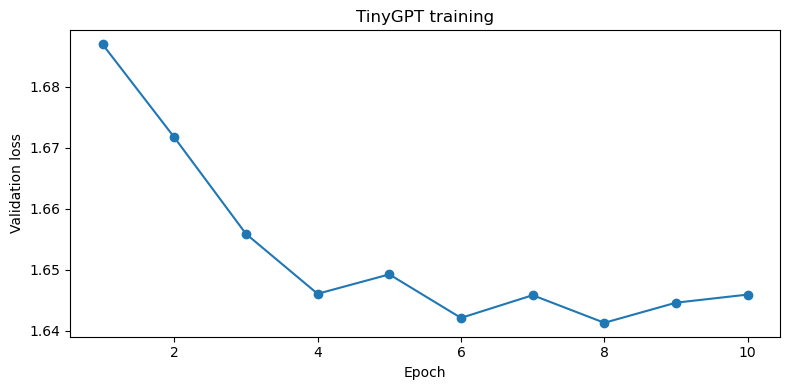

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.title('TinyGPT training')
plt.tight_layout()
plt.show()

## Generate Text

In [27]:
def generate_text(model, start, length, temperature=0.8):
    """
    Generate readable text from a seed string.

    Parameters:
        model (nn.Module): Trained model.
        start (str): Seed text.
        length (int): Number of characters to generate.
        temperature (float): Sampling temperature.

    Returns:
        str: The generated text.
    """
    model.eval()
    idx = torch.tensor([[STOI[ch] for ch in start]], device=DEVICE)
    with torch.no_grad():
        out = model.generate(idx, length)
    return ''.join(ITOS[i] for i in out[0].tolist())

In [28]:
print(generate_text(model, 'ROMEO: ', 400))

ROMEO: froy,
A king up baitish slain glorious of cunning suppore:
From your unharning hung to language's grounded,
That is to piece on in selfsame expetunand'st of him that
We did age nor like two objurey:
Having that he thoughts mincting such,
Is breacherous previolence livings, his that shall night;
That news made against thy arm are mock,
That first only as you mank, the faster
Than death he had which


## Save Model

In [29]:
torch.save(model.state_dict(), 'models/tinygpt_shakespeare.pt')
print('saved tinygpt_shakespeare.pt')

saved tinygpt_shakespeare.pt


## Load Model

In [30]:
loaded_model = TinyGPT(VOCAB_SIZE, EMBED_DIM, N_HEADS, N_LAYERS, BLOCK_SIZE, FF_DIM).to(DEVICE)
loaded_model.load_state_dict(torch.load('models/tinygpt_shakespeare.pt', map_location=DEVICE))
loaded_model.eval()
print('loaded tinygpt_shakespeare.pt')

loaded tinygpt_shakespeare.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_77603/3026413204.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('mode

## Inference

In [31]:
print(generate_text(loaded_model, 'JULIET: ', 400))

JULIET: I am ind the oddit of chance
We rooth better to have!

DUKE VINCENTIO:
Sirrah, that even to them
When he comes this disposition in should
And say I'll says troublingess friends function?
O let it is ut condry Flanterposing:
But for than you chamber?
What, show yours, this along. Would have sentenched nocked by challed living
To violent thy pleasure
Thus here against you bring along
To visit on my 
